# Bilinear Interpolation

**Bilinear Interpolation** is a method used for resizing images that considers the closest four pixels in the original image to compute the value of each pixel in the resized image. It provides smoother results compared to Nearest Neighbor Upsampling by taking into account the weighted average of the surrounding pixels.

## Mathematical Explanation

1. **Original Image and Resizing:**
   - Let $( I )$ be the original image with dimensions $( H \times W )$ (Height × Width).
   - We aim to resize $( I )$ to a new image with dimensions $( H' \times W' )$, where $( H' )$ and $( W' )$ are the new dimensions.

2. **Scaling Factors:**
   - Define scaling factors $( \alpha )$ and $( \beta )$ for the height and width dimensions:
     $$
     \alpha = \frac{H'}{H}
     $$
     $$
     \beta = \frac{W'}{W}
     $$
   - These scaling factors represent how much larger the resized image will be compared to the original image.

3. **Pixel Mapping:**
   - For a pixel at coordinates $( (x', y') )$ in the resized image, calculate the corresponding position in the original image:
     $$
     x = \frac{x'}{\alpha}
     $$
     $$
     y = \frac{y'}{\beta}
     $$
   - $( (x, y) )$ is typically a non-integer value.

4. **Interpolation:**
   - To compute the pixel value at $( (x', y') )$, find the four surrounding pixels in the original image:
     - $( (x_1, y_1) )$ is the pixel at the top-left corner
     - $( (x_1, y_2) )$ is the pixel at the bottom-left corner
     - $( (x_2, y_1) )$ is the pixel at the top-right corner
     - $( (x_2, y_2) )$ is the pixel at the bottom-right corner

   - Compute the weights for interpolation based on the distance from $( (x, y) )$ to these four surrounding pixels:
     - Let $( x_1 = \lfloor x \rfloor )$ and $( x_2 = \lceil x \rceil )$
     - Let $( y_1 = \lfloor y \rfloor )$ and $( y_2 = \lceil y \rceil )$
     - Weights are:
       $$
       w_{11} = (x_2 - x) \cdot (y_2 - y)
       $$
       $$
       w_{21} = (x - x_1) \cdot (y_2 - y)
       $$
       $$
       w_{12} = (x_2 - x) \cdot (y - y_1)
       $$
       $$
       w_{22} = (x - x_1) \cdot (y - y_1)
       $$

   - Compute the pixel value $( I'(x', y') )$ using these weights:
     $$
     I'(x', y') = w_{11} \cdot I(x_1, y_1) + w_{21} \cdot I(x_2, y_1) + w_{12} \cdot I(x_1, y_2) + w_{22} \cdot I(x_2, y_2)
     $$

## Practical Considerations

1. **Smoothing and Quality:**
   - Bilinear interpolation provides smoother results compared to Nearest Neighbor, reducing blockiness and producing better quality images.

2. **Computational Complexity:**
   - While more complex than Nearest Neighbor, bilinear interpolation is still computationally efficient and widely used in image processing.

3. **Applications:**
   - Commonly used in image scaling tasks where a balance between quality and computational efficiency is needed.

## Example Code

Here is a Python code snippet using the `PIL` library to perform Bilinear Interpolation for upsampling:

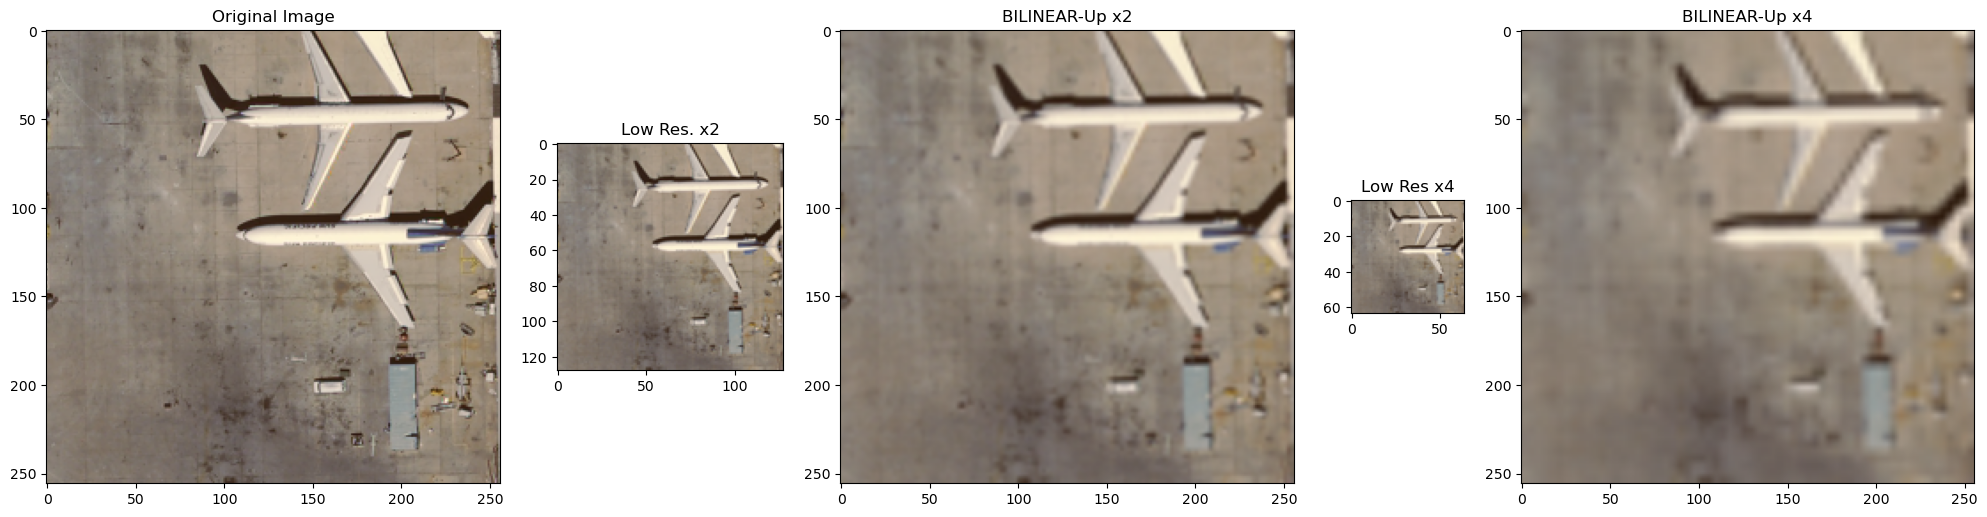

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

def bilinear_upsample(image, scale_factor):
    # Resize the image using bilinear interpolation
    return image.resize(
        (int(image.width * scale_factor), int(image.height * scale_factor)), 
        Image.BILINEAR
    )

# Load an image
image_hr = Image.open('./images/image_hr.png').convert('RGB')
image_lr_2 = Image.open('./images/image_lr_2.png').convert('RGB')
image_lr_4 = Image.open('./images/image_lr_4.png').convert('RGB')

# Perform upsampling with a scale factor of 2
scaled_image_2 = bilinear_upsample(image_lr_2, scale_factor=2)
scaled_image_4 = bilinear_upsample(image_lr_4, scale_factor=4)

# Create a figure with subplots
fig, axs = plt.subplots(1, 5, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 0.5, 1, 0.25, 1]})

# Display each image in a subplot
axs[0].imshow(image_hr)
axs[0].set_title('Original Image')
axs[0].axis('on')

axs[1].imshow(image_lr_2)
axs[1].set_title('Low Res. x2')
axs[1].axis('on')

axs[2].imshow(scaled_image_2)
axs[2].set_title('BILINEAR-Up x2')
axs[2].axis('on')

axs[3].imshow(image_lr_4)
axs[3].set_title('Low Res x4')
axs[3].axis('on')

axs[4].imshow(scaled_image_4)
axs[4].set_title('BILINEAR-Up x4')
axs[4].axis('on')

# Adjust the layout to fit the images properly
plt.tight_layout()
plt.show()